In [64]:
print("hello")

hello


cv_ch02 파일 

In [65]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False

In [66]:
import torch
import numpy as np

In [67]:
# 2.4 차 함수의 경사 계산

In [68]:
x_np = np.arange(-2, 2.1, 0.25)
print(x_np)

[-2.   -1.75 -1.5  -1.25 -1.   -0.75 -0.5  -0.25  0.    0.25  0.5   0.75
  1.    1.25  1.5   1.75  2.  ]


In [69]:
# (1) 경사 계산용 변수 정의
x = torch.tensor(x_np, requires_grad=True,
                 dtype=torch.float32)
print(x)

tensor([-2.0000, -1.7500, -1.5000, -1.2500, -1.0000, -0.7500, -0.5000, -0.2500,
         0.0000,  0.2500,  0.5000,  0.7500,  1.0000,  1.2500,  1.5000,  1.7500,
         2.0000], requires_grad=True)


In [70]:
# 2차 함수의 계산 : 계산 그래프는 내부에서 자동 생성됨
y = 2*x**2 + 2

# y의 계산 결과 확인
print(y)

tensor([10.0000,  8.1250,  6.5000,  5.1250,  4.0000,  3.1250,  2.5000,  2.1250,
         2.0000,  2.1250,  2.5000,  3.1250,  4.0000,  5.1250,  6.5000,  8.1250,
        10.0000], grad_fn=<AddBackward0>)


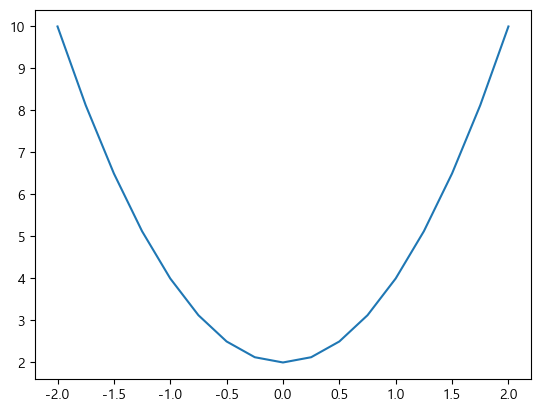

In [71]:
# 그래프 출력

plt.plot(x.data, y.data)
plt.show()

In [72]:
# 경사 계산을 위해 최종 값은 스칼라일 필요가 있음
# 더미로 sum 함수를 붙임

z = y.sum()

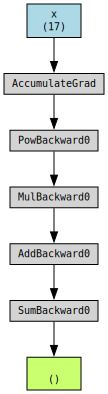

In [73]:
# (3) 계산 그래프 시각화

# 설치 : !pip install torchviz

from torchviz import make_dot

# 시각화 함수 호출
g = make_dot(z, params={'x': x})
display(g)

In [74]:
# (4) 경사 계산
z.backward()

In [75]:
# (5) 경삿값 가져오기
print(x.grad)


tensor([-8., -7., -6., -5., -4., -3., -2., -1.,  0.,  1.,  2.,  3.,  4.,  5.,
         6.,  7.,  8.])


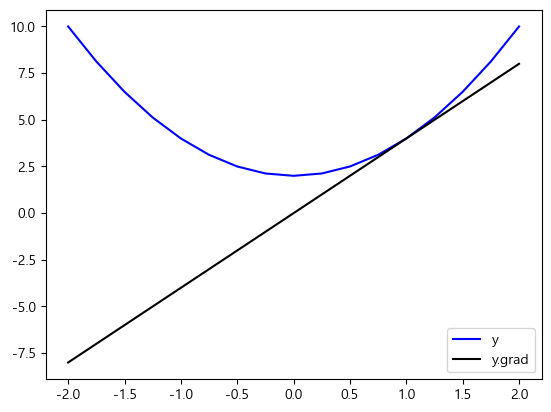

In [76]:
# 원래 함수의 경사 그래프
plt.plot(x.data, y.data, c='b', label='y')
plt.plot(x.data, x.grad.data, c='k', label = 'y.grad')
plt.legend()
plt.show()

In [77]:
# 경삿값 초기화의 필요성 예시
# 경사를 초기화하지 않고 두번째 경사를 계산

y=2*x**2+2
z=y.sum()
z.backward()

print(x.grad)

tensor([-16., -14., -12., -10.,  -8.,  -6.,  -4.,  -2.,   0.,   2.,   4.,   6.,
          8.,  10.,  12.,  14.,  16.])


이 경삿값은 경사 계산의 값이 점차 합해진 결과.
새로운 값 계산을 위해서는 반드시 경삿값을 초기화 해야함.

In [78]:
# (6) 경삿값의 초기화는 zero_() 함수를 사용함
x.grad.zero_()
print(x.grad)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])


### 2.5 시그모이드 함수의 경사 계산

In [79]:
# (1) 시그모이드 함수의 정의
sigmoid = torch.nn.Sigmoid()

In [80]:
# (2) y값의 계산
y=sigmoid(x) # x는 앞의 x와 동일한 텐서임

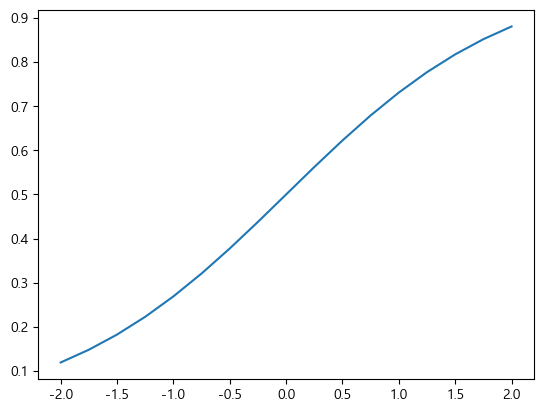

In [81]:
# 그래프 출력
plt.plot(x.data, y.data)
plt.show()

In [82]:
# 경사 계산을 위해 최종 값은 스칼라일 필요가 있음
# 더미로 sum 함수를 붙임
z = y.sum()

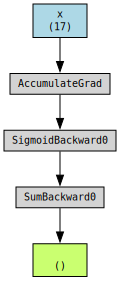

In [83]:
# (3) 계산 그래프 시각화
g = make_dot(z,params={'x': x})
display(g)

In [84]:
# (4) 경사 계산
z.backward()

In [85]:
# (5) 경삿값 확인
print(x.grad)

tensor([0.1050, 0.1261, 0.1491, 0.1731, 0.1966, 0.2179, 0.2350, 0.2461, 0.2500,
        0.2461, 0.2350, 0.2179, 0.1966, 0.1731, 0.1491, 0.1261, 0.1050])


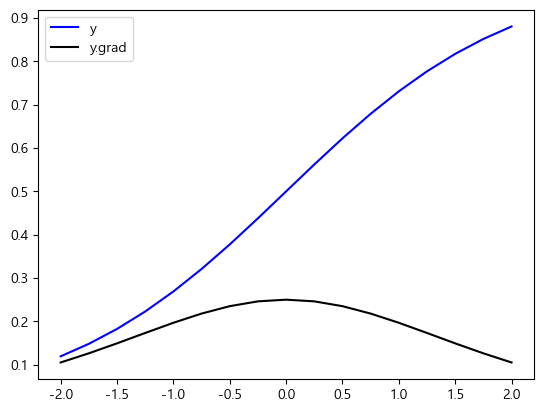

In [86]:
# 원래 함수와 경사 그래프
plt.plot(x.data, y.data, c='b', label='y')
plt.plot(x.data, x.grad.data, c='k', label = 'y.grad')
plt.legend()
plt.show()

In [87]:
# (6) 경사 초기화는 zero_() 함수를 사용
x.grad.zero_()
print(x.grad)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])


시그모이드 함수를 직접 구현한 경우

In [88]:
# 시그모이드 함수의 정의
def sigmoid(x):
    return (1/(1+torch.exp(-x)))

In [89]:
# (2) y값의 계산
y = sigmoid(x)

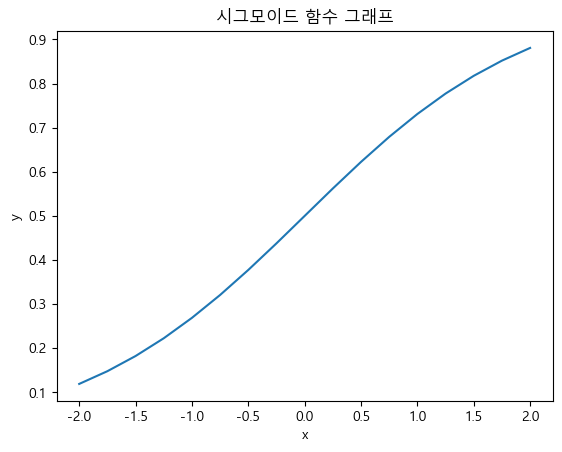

In [90]:
# 그래프 출력
plt.plot(x.data, y.data)
plt.xlabel('x')
plt.ylabel('y')
plt.title('시그모이드 함수 그래프')
plt.show()

In [91]:
# 경사 계산을 위해 최종 값은 스칼라일 필요가 있음
# 더미로 sum 함수를 붙임
z = y.sum()

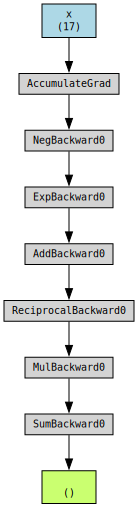

In [92]:
# (3) 계산 그래프 시각화
params = {'x': x}
g = make_dot(z, params=params)
display(g)

In [93]:
# (4) 경사 계산
z.backward()

# (5) 경삿값 확인
print(x.grad)

tensor([0.1050, 0.1261, 0.1491, 0.1731, 0.1966, 0.2179, 0.2350, 0.2461, 0.2500,
        0.2461, 0.2350, 0.2179, 0.1966, 0.1731, 0.1491, 0.1261, 0.1050])


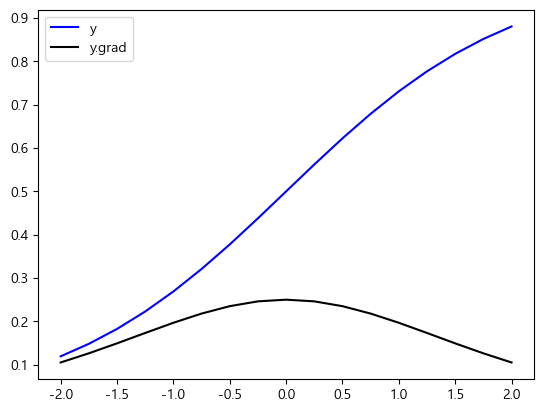

In [94]:
# 원래 함수와 경사 그래프
plt.plot(x.data, y.data, c='b', label='y')
plt.plot(x.data, x.grad.data, c='k', label = 'y.grad')
plt.legend()
plt.show()

# 3장

In [95]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False

In [96]:
import torch
from torchviz import make_dot
import numpy as np

### 3.5 데이터 전처리

In [97]:
# 샘플 데이터 선언
sampleData1 = np.array([
    [166, 58.7],
    [176.0, 75.7],
    [171.0, 62.1],
    [173.0, 70.4],
    [169.0,60.1]
])
print(sampleData1)

# 머신러닝 모델에서 사용하기 위해, 신장을 변수 x로,
# 체중을 변수 y로 선언

x = sampleData1[:, 0] # 신장
y = sampleData1[:, 1] # 체중

[[166.   58.7]
 [176.   75.7]
 [171.   62.1]
 [173.   70.4]
 [169.   60.1]]


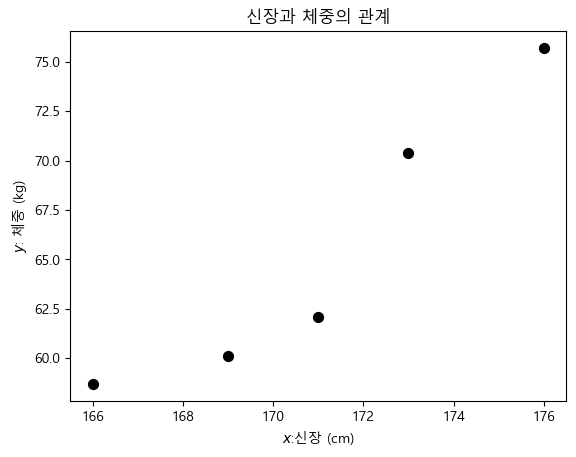

In [98]:
# 산포도 출력 확인

plt.scatter(x, y, c = 'k', s=50)
plt.xlabel('$x$:신장 (cm)')
plt.ylabel('$y$: 체중 (kg)')
plt.title('신장과 체중의 관계')
plt.show()

### 데이터 변환

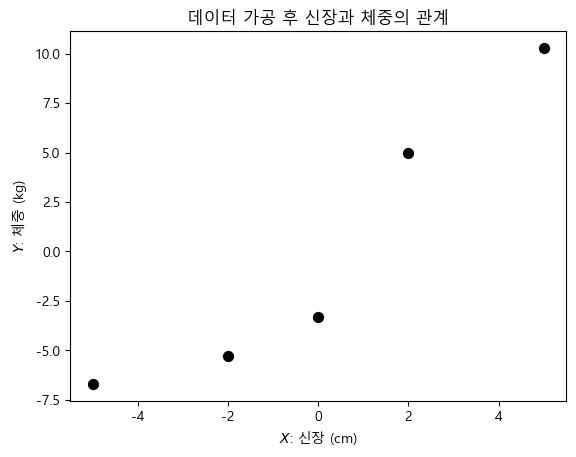

In [99]:
X = x-x.mean()
Y = y-y.mean()

# 산포도를 통해 결과 확인
plt.scatter(X, Y, c = 'k', s=50)
plt.xlabel('$X$: 신장 (cm)')
plt.ylabel('$Y$: 체중 (kg)')
plt.title('데이터 가공 후 신장과 체중의 관계')
plt.show()

### 3.6 예측 계산

In [100]:
# X와 Y를 텐서 변수로 변환
X = torch.tensor(X).float()
Y = torch.tensor(Y).float()

# 결과 확인
print(X)
print(Y)


tensor([-5.,  5.,  0.,  2., -2.])
tensor([-6.7000, 10.3000, -3.3000,  5.0000, -5.3000])


실습 때 바꾸기

In [101]:
# 파라미터 정의
# W와 B는 경사하강법 대상; 경사 계산을 위해, requires_grad=True로 선언
W = torch.tensor(1.0, requires_grad=True)
B = torch.tensor(1.0, requires_grad=True)

In [102]:
# 예측 함수는 1차 함수
def pred(X):
    return W*X + B

# 예측 값 계산
Yp = pred(X)

# 결과 확인
print(Yp)

tensor([-4.,  6.,  1.,  3., -1.], grad_fn=<AddBackward0>)


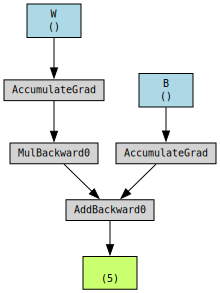

In [103]:
# 예측 값의 계산 그래프 표시
params = {'W': W, 'B': B}
g = make_dot(Yp, params=params)
display(g)

### 3.7 손실 게산

In [104]:
# 평균 제곱 오차 손실함수
def mse(Yp, Y):
    loss  = ((Yp - Y)**2).mean()
    return loss

# 손실 계산
loss = mse(Yp, Y)

# 결과 표시
print(loss)

tensor(13.3520, grad_fn=<MeanBackward0>)


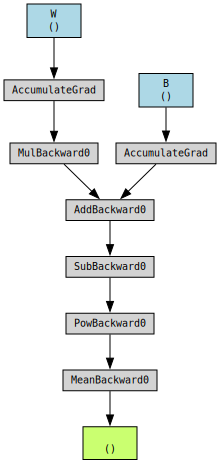

In [105]:
# 손실 계산 그래프 출력
params = {'W': W, 'B': B}
g = make_dot(loss, params=params)
display(g)

### 3.8 경사 계산

In [106]:
# 경사 계산
loss.backward()

# 경삿값 확인
print(W.grad)
print(B.grad)


tensor(-19.0400)
tensor(2.0000)


### 3.9 파라미터 수정

In [107]:
# 학습률 정의
lr = 0.001

# 경사를 기반으로 파라미터 수정
# with torch.no_grad() 작성 필요
# 블록 안에서는, 텐서의 requires_grad 속성이 True로 설정되어 있어도, 연산이 계산 그래프에 기록되지 않음
with torch.no_grad():
    W -= lr * W.grad
    B -= lr * B.grad
    
    # 계산이 끝난 경삿값을 초기화함
    W.grad.zero_()
    B.grad.zero_()

# 파라미터 경삿값 확인
print(W)
print(B)
print(W.grad)
print(B.grad)

tensor(1.0190, requires_grad=True)
tensor(0.9980, requires_grad=True)
tensor(0.)
tensor(0.)


### 3.10 반복 계산

In [108]:
# 초기화

# W와 B를 변수로 사용
W = torch.tensor(1.0, requires_grad=True).float()
B = torch.tensor(1.0, requires_grad=True).float()

# 반복 횟수
num_epochs = 500

# 학습률
lr = 0.001

# history 기록을 위한 배열 초기화
history = np.zeros((0,2))

In [109]:
# 루프 처리
for epoch in range(num_epochs):
    # 예측 계산
    Yp = pred(X)
    
    # 손실 계산
    loss = mse(Yp, Y)
    
    # 경사 계산
    loss.backward()
    
    # 파라미터 수정
    with torch.no_grad():
        W -= lr * W.grad
        B -= lr * B.grad
        
        # 계산이 끝난 경삿값을 초기화함
        W.grad.zero_()
        B.grad.zero_()
        
    # 손실 기록
    if (epoch %10 == 0):
        item = np.array([epoch, loss.item()])
        history = np.vstack((history, item))
        print(f'epoch = {epoch}, loss = {loss:.4f}')

epoch = 0, loss = 13.3520
epoch = 10, loss = 10.3855
epoch = 20, loss = 8.5173
epoch = 30, loss = 7.3364
epoch = 40, loss = 6.5858
epoch = 50, loss = 6.1047
epoch = 60, loss = 5.7927
epoch = 70, loss = 5.5868
epoch = 80, loss = 5.4476
epoch = 90, loss = 5.3507
epoch = 100, loss = 5.2805
epoch = 110, loss = 5.2275
epoch = 120, loss = 5.1855
epoch = 130, loss = 5.1507
epoch = 140, loss = 5.1208
epoch = 150, loss = 5.0943
epoch = 160, loss = 5.0703
epoch = 170, loss = 5.0480
epoch = 180, loss = 5.0271
epoch = 190, loss = 5.0074
epoch = 200, loss = 4.9887
epoch = 210, loss = 4.9708
epoch = 220, loss = 4.9537
epoch = 230, loss = 4.9373
epoch = 240, loss = 4.9217
epoch = 250, loss = 4.9066
epoch = 260, loss = 4.8922
epoch = 270, loss = 4.8783
epoch = 280, loss = 4.8650
epoch = 290, loss = 4.8522
epoch = 300, loss = 4.8399
epoch = 310, loss = 4.8281
epoch = 320, loss = 4.8167
epoch = 330, loss = 4.8058
epoch = 340, loss = 4.7953
epoch = 350, loss = 4.7853
epoch = 360, loss = 4.7756
epoch = 37

### 3.11 결과 평가

In [110]:
# 최종 파라미터 값
print('W = ', W.data.numpy())
print('B = ', B.data.numpy())

# 손실 확인
print(f'초기상태 : 손실 : {history[0,1]:.4f}')
print(f'최종상태 : 손실 : {history[-1,1]:.4f}')

W =  1.820683
B =  0.3675114
초기상태 : 손실 : 13.3520
최종상태 : 손실 : 4.6796


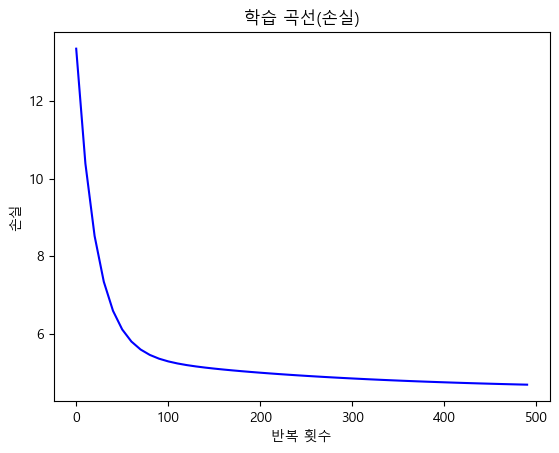

In [111]:
# 학습 곡선 출력(손실)
plt.plot(history[:,0], history[:,1], c='b')
plt.xlabel('반복 횟수')
plt.ylabel('손실')
plt.title('학습 곡선(손실)')
plt.show()

산포도에 회귀 직선을 동시에 출력함

In [112]:
# x의 범위를 구함 (Xrange)
X_max = X.max()
X_min = X.min()
X_range = np.array((X_min, X_max))
X_range = torch.from_numpy(X_range).float()
print(X_range)

# 이와 대응하는 예측값 y를 구함
Y_range = pred(X_range)
print(Y_range.data)

tensor([-5.,  5.])
tensor([-8.7359,  9.4709])


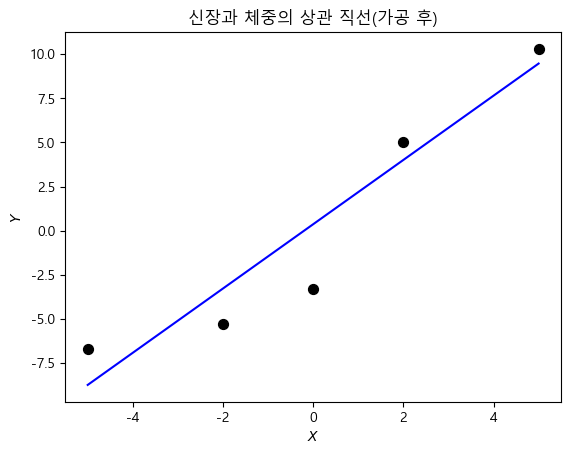

In [113]:
# 그래프 출력
plt.scatter(X, Y, c='k', s=50)
plt.xlabel('$X$')
plt.ylabel('$Y$')
plt.plot(X_range.data, Y_range.data, c='b')
plt.title('신장과 체중의 상관 직선(가공 후)')
plt.show()

가공 전 데이터로 회귀 직선 출력

In [114]:
# y좌표와 x좌표 값 계산
x_range = X_range+x.mean()
yp_range = Y_range+y.mean()

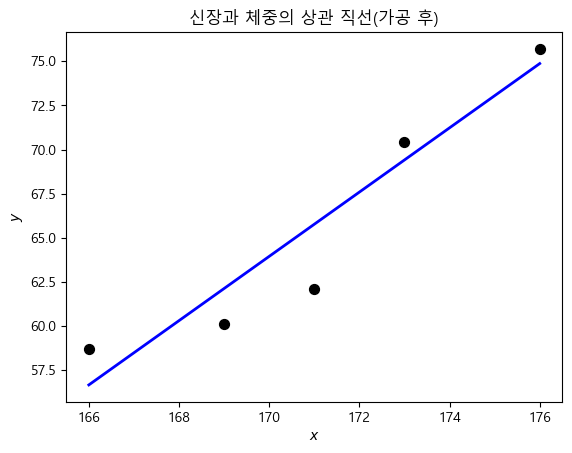

In [115]:
# 그래프 출력
plt.scatter(x, y, c='k', s=50)
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.plot(x_range, yp_range.data, lw=2, c='b')
plt.title('신장과 체중의 상관 직선(가공 후)')
plt.show()

### 3.12 최적화 함수와 step 함수 이용하기

In [116]:
# 초기화

# W와 B를 변수로 사용
W = torch.tensor(1.0, requires_grad=True).float()
B = torch.tensor(1.0, requires_grad=True).float()

# 반복 횟수
num_epochs = 500

# 학습률
lr = 0.001

# optimizer 로 SGD(확률적 경사 하강법)을 사용
import torch.optim as optim
optimizer = optim.SGD([W, B], lr=lr)

# history 기록을 위한 배열 초기화
history = np.zeros((0,2))

In [117]:
# 루프 처리
for epoch in range(num_epochs):
    # 예측 계산
    Yp = pred(X)
    
    # 손실 계산
    loss = mse(Yp, Y)
    
    # 경사 계산
    loss.backward()
    
    # 파라미터 수정
    optimizer.step()
    
    # 경사 초기화
    optimizer.zero_grad() 
    
    # 손실 기록
    if (epoch %10 == 0):
        item = np.array([epoch, loss.item()])
        history = np.vstack((history, item))
        print(f'epoch = {epoch}, loss = {loss:.4f}')

epoch = 0, loss = 13.3520
epoch = 10, loss = 10.3855
epoch = 20, loss = 8.5173
epoch = 30, loss = 7.3364
epoch = 40, loss = 6.5858
epoch = 50, loss = 6.1047
epoch = 60, loss = 5.7927
epoch = 70, loss = 5.5868
epoch = 80, loss = 5.4476
epoch = 90, loss = 5.3507
epoch = 100, loss = 5.2805
epoch = 110, loss = 5.2275
epoch = 120, loss = 5.1855
epoch = 130, loss = 5.1507
epoch = 140, loss = 5.1208
epoch = 150, loss = 5.0943
epoch = 160, loss = 5.0703
epoch = 170, loss = 5.0480
epoch = 180, loss = 5.0271
epoch = 190, loss = 5.0074
epoch = 200, loss = 4.9887
epoch = 210, loss = 4.9708
epoch = 220, loss = 4.9537
epoch = 230, loss = 4.9373
epoch = 240, loss = 4.9217
epoch = 250, loss = 4.9066
epoch = 260, loss = 4.8922
epoch = 270, loss = 4.8783
epoch = 280, loss = 4.8650
epoch = 290, loss = 4.8522
epoch = 300, loss = 4.8399
epoch = 310, loss = 4.8281
epoch = 320, loss = 4.8167
epoch = 330, loss = 4.8058
epoch = 340, loss = 4.7953
epoch = 350, loss = 4.7853
epoch = 360, loss = 4.7756
epoch = 37

In [118]:
# 최종 파라미터 값
print('W = ', W.data.numpy())
print('B = ', B.data.numpy())

# 손실 확인
print(f'초기상태 : 손실 : {history[0,1]:.4f}')
print(f'최종상태 : 손실 : {history[-1,1]:.4f}')

W =  1.820683
B =  0.3675114
초기상태 : 손실 : 13.3520
최종상태 : 손실 : 4.6796


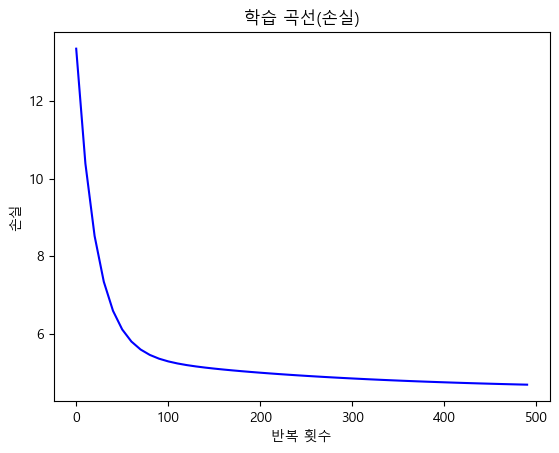

In [119]:
# 학습 곡선 출력 (손실)
plt.plot(history[:,0], history[:,1], c='b')
plt.xlabel('반복 횟수')
plt.ylabel('손실')
plt.title('학습 곡선(손실)')
plt.show()

In [120]:
# 초기화
# W와 B를 변수로 사용
W = torch.tensor(1.0, requires_grad=True).float()
B = torch.tensor(1.0, requires_grad=True).float()

# 반복 횟수
num_epochs = 500

# 학습률
lr = 0.001

# optimizer로 SGD(확률적 경사 하강법)을 사용
import torch.optim as optim
optimizer = optim.SGD([W, B], lr=lr, momentum=0.9)
# momentum 함수로 튜닝

# history 기록을 위한 배열 초기화
history2 = np.zeros((0,2))

In [121]:
# 루프 처리
for epoch in range(num_epochs):
    # 예측 계산
    Yp = pred(X)
    
    # 손실 계산
    loss = mse(Yp, Y)
    
    # 경사 계산
    loss.backward()
    
    # 파라미터 수정
    optimizer.step()
    
    # 경사 초기화
    optimizer.zero_grad() 
    
    # 손실 기록
    if (epoch %10 == 0):
        item = np.array([epoch, loss.item()])
        history2 = np.vstack((history2, item))
        print(f'epoch = {epoch}, loss = {loss:.4f}')

epoch = 0, loss = 13.3520
epoch = 10, loss = 5.7585
epoch = 20, loss = 5.9541
epoch = 30, loss = 5.0276
epoch = 40, loss = 4.8578
epoch = 50, loss = 4.7052
epoch = 60, loss = 4.6327
epoch = 70, loss = 4.5940
epoch = 80, loss = 4.5698
epoch = 90, loss = 4.5574
epoch = 100, loss = 4.5495
epoch = 110, loss = 4.5452
epoch = 120, loss = 4.5426
epoch = 130, loss = 4.5411
epoch = 140, loss = 4.5403
epoch = 150, loss = 4.5398
epoch = 160, loss = 4.5395
epoch = 170, loss = 4.5393
epoch = 180, loss = 4.5392
epoch = 190, loss = 4.5391
epoch = 200, loss = 4.5391
epoch = 210, loss = 4.5391
epoch = 220, loss = 4.5391
epoch = 230, loss = 4.5390
epoch = 240, loss = 4.5390
epoch = 250, loss = 4.5390
epoch = 260, loss = 4.5390
epoch = 270, loss = 4.5390
epoch = 280, loss = 4.5390
epoch = 290, loss = 4.5390
epoch = 300, loss = 4.5390
epoch = 310, loss = 4.5390
epoch = 320, loss = 4.5390
epoch = 330, loss = 4.5390
epoch = 340, loss = 4.5390
epoch = 350, loss = 4.5390
epoch = 360, loss = 4.5390
epoch = 370

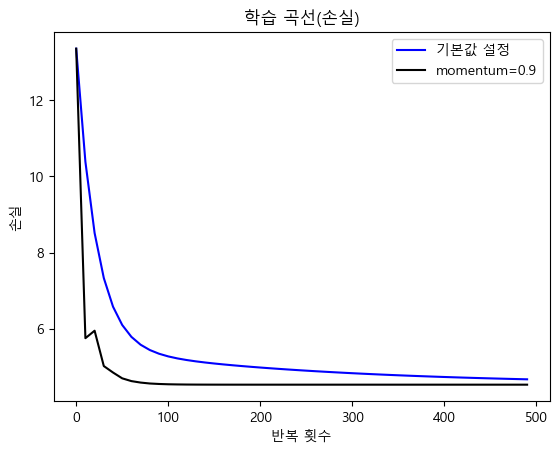

In [123]:
# 학습 곡선(손실) 출력
plt.plot(history[:,0], history[:,1], 'b', label='기본값 설정')
plt.plot(history2[:,0], history2[:,1], 'k', label='momentum=0.9')
plt.xlabel('반복 횟수')
plt.ylabel('손실')
plt.legend()
plt.title('학습 곡선(손실)')
plt.show()

In [124]:
# 최종 파라미터 값
print('W = ', W.data.numpy())
print('B = ', B.data.numpy())

# 손실 확인
print(f'초기상태 : 손실 : {history[0,1]:.4f}')
print(f'최종상태 : 손실 : {history[-1,1]:.4f}')

W =  1.8206898
B =  2.2701947e-06
초기상태 : 손실 : 13.3520
최종상태 : 손실 : 4.6796


# 실습문제

3.12 최적호 함수와 step 함수 이용하기


W = torch.randn(1,requires_grad=True)

B = torch.randn(1,requires_grad=True)

손실함수, W, B 찍기


In [125]:
W = torch.randn(1,requires_grad=True)

B = torch.randn(1,requires_grad=True)

In [126]:

# 반복 횟수
num_epochs = 500

# 학습률
lr = 0.001

# optimizer 로 SGD(확률적 경사 하강법)을 사용
import torch.optim as optim
optimizer = optim.SGD([W, B], lr=lr)

# history 기록을 위한 배열 초기화
history = np.zeros((0, 2))

In [127]:
# 루프 처리

for epoch in range(num_epochs):

    # 예측 계산
    Yp = pred(X)
    
    # 손실 계산
    loss = mse(Yp, Y)

    # 경사 계산
    loss.backward()

    # 파라미터 수정
    optimizer.step()
    
    # 경삿값 초기화
    optimizer.zero_grad()
        
    # 손실 기록
    if (epoch %10 == 0):
        item = np.array([epoch, loss.item()])
        history = np.vstack((history, item))
        print(f'epoch = {epoch}  loss = {loss:.4f}')

epoch = 0  loss = 87.0463
epoch = 10  loss = 56.1726
epoch = 20  loss = 36.8646
epoch = 30  loss = 24.7891
epoch = 40  loss = 17.2365
epoch = 50  loss = 12.5123
epoch = 60  loss = 9.5567
epoch = 70  loss = 7.7073
epoch = 80  loss = 6.5496
epoch = 90  loss = 5.8244
epoch = 100  loss = 5.3699
epoch = 110  loss = 5.0846
epoch = 120  loss = 4.9052
epoch = 130  loss = 4.7920
epoch = 140  loss = 4.7203
epoch = 150  loss = 4.6745
epoch = 160  loss = 4.6450
epoch = 170  loss = 4.6257
epoch = 180  loss = 4.6129
epoch = 190  loss = 4.6041
epoch = 200  loss = 4.5978
epoch = 210  loss = 4.5932
epoch = 220  loss = 4.5896
epoch = 230  loss = 4.5868
epoch = 240  loss = 4.5843
epoch = 250  loss = 4.5822
epoch = 260  loss = 4.5803
epoch = 270  loss = 4.5785
epoch = 280  loss = 4.5769
epoch = 290  loss = 4.5753
epoch = 300  loss = 4.5739
epoch = 310  loss = 4.5725
epoch = 320  loss = 4.5712
epoch = 330  loss = 4.5699
epoch = 340  loss = 4.5687
epoch = 350  loss = 4.5675
epoch = 360  loss = 4.5664
epoch 

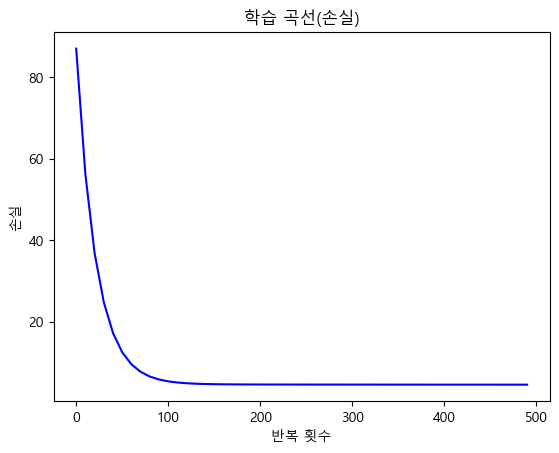

In [128]:
# 학습 곡선 출력(손실)

plt.plot(history[:,0], history[:,1], 'b')
plt.xlabel('반복 횟수')
plt.ylabel('손실')
plt.title('학습 곡선(손실)')
plt.show()

In [129]:
# 최종 파라미터 값
print('W = ', W.data.numpy())
print('B = ', B.data.numpy())

# 손실 확인
print(f'초기상태 : 손실:{history[0,1]:.4f}') 
print(f'최종상태 : 손실:{history[-1,1]:.4f}') 

W =  [1.8206683]
B =  [0.12497002]
초기상태 : 손실:87.0463
최종상태 : 손실:4.5553
